# Demonstração: classificação de sentimento em português (RePro)

Nesta demonstração, seguimos um fluxo simples e alinhado à Aula 10. O objetivo é treinar um classificador de sentimento em português do Brasil usando o dataset RePro e avaliar o desempenho com métricas básicas.

## 1. Importações e configuração
Aqui carregamos as bibliotecas necessárias e definimos uma semente para reprodutibilidade.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

%matplotlib inline

SEED = 42
np.random.seed(SEED)

## 2. Carregar o dataset RePro
O dataset está disponível publicamente no Hugging Face. Vamos carregar diretamente do CSV.

In [2]:
DATA_URL = 'https://huggingface.co/datasets/lucasnil/repro/resolve/main/RePro.csv'

df = pd.read_csv(DATA_URL)
df.head()

,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,review_text,overall_rating,...,reviewer_gender,reviewer_state,topics,polarity,ENTREGA,OUTROS,PRODUTO,CONDICOESDERECEBIMENTO,INADEQUADA,ANUNCIO
0,2018-05-14 13:57:59,a4380c38e7e73687066bf66329454b33e7749a8b49ad1a...,34398895,Kit Com 10 Cuecas Boxer de Cotton 4.0 - Polo M...,NaN,Moda,Masculino,"""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A AMERICAN...","ESSE PRODUTO PODE ATÉ SER BOM, PORÉM, A AMERIC...",3,...,M,SP,"['ENTREGA', 'OUTROS']","['NEGATIVO', 'POSITIVO']",1,1,0,0,0,0
1,2018-01-18 12:02:42,fbf1d015682ddd45f97cedbc935fd42e42325498e68cd4...,132444050,Smartphone Motorola Moto G 5S Dual Chip Androi...,NaN,Celulares e Smartphones,Smartphone,"""compra sem susto""","Aparelho muito bom, confiável e com valor aqui...",4,...,M,ES,['PRODUTO'],['POSITIVO'],0,0,1,0,0,0
2,2018-04-18 12:06:14,6042f06b0d63fd46499b2f6eed116df96cc8f2649df8f3...,132710805,Impressora Hp Sprocket 100 Jato de Tinta,NaN,Câmeras e Filmadoras,Impressora e Papel Fotográfico,*,"As cores da impressão não são fiéis, O custo b...",3,...,F,MG,['PRODUTO'],['NEGATIVO'],0,0,1,0,0,0
3,2018-01-23 08:11:11,4871f745136a74808a49970db18d205fd66cb666acabb2...,119882282,Livro - It: A Coisa,NaN,Livros,Literatura Estrangeira,***,"A história é muito boa, porém o autor ""enrolou...",3,...,F,MG,['PRODUTO'],"['NEGATIVO', 'POSITIVO']",0,0,1,0,0,0
4,2018-02-17 11:19:38,6141e659c620ab597a5cda1b9150e180f7337434260eee...,23218825,Termometro Laser Digital Infravermelho Febre D...,NaN,Bebês,Higiene e Saúde,****,"Entrega rápida, produto muito bom Amei. Pratic...",4,...,F,SP,"['ENTREGA', 'PRODUTO']",['POSITIVO'],1,0,1,0,0,0


## 3. Selecionar texto e rótulo
Vamos combinar título e texto da avaliação quando disponível.

In [3]:
df['review_title'] = df['review_title'].fillna('')
df['review_text'] = df['review_text'].fillna('')

df['text'] = (df['review_title'] + ' ' + df['review_text']).str.strip()

df[['text', 'polarity']].head()

,text,polarity
0,"""O PRODUTO QUE NÃO ESTÁ AGRADANDO É A AMERICAN...","['NEGATIVO', 'POSITIVO']"
1,"""compra sem susto"" Aparelho muito bom, confiáv...",['POSITIVO']
2,"* As cores da impressão não são fiéis, O custo...",['NEGATIVO']
3,"*** A história é muito boa, porém o autor ""enr...","['NEGATIVO', 'POSITIVO']"
4,"**** Entrega rápida, produto muito bom Amei. P...",['POSITIVO']


## 4. Normalizar rótulos de polaridade
A coluna `polarity` pode aparecer como lista de rótulos. Vamos padronizar para quatro classes: POSITIVO, NEGATIVO, NEUTRO e MISTO.

In [4]:
def normalize_polarity(value):
    if pd.isna(value):
        return None
    if isinstance(value, list):
        labels = value
    else:
        s = str(value).strip()
        if s.startswith('[') and s.endswith(']'):
            s = s[1:-1]
            labels = [t.strip().strip("'") for t in s.split(',') if t.strip()]
        else:
            labels = [s]

    labels = [l.upper() for l in labels]
    joined = ' '.join(labels)

    if 'NEGATIVO' in joined and 'POSITIVO' in joined:
        return 'MISTO'
    if 'POSITIVO' in joined:
        return 'POSITIVO'
    if 'NEGATIVO' in joined:
        return 'NEGATIVO'
    if 'NEUTRO' in joined:
        return 'NEUTRO'
    return None

df['label'] = df['polarity'].apply(normalize_polarity)
df = df[df['text'].str.len() > 0]
df = df[df['label'].notna()]

df['label'].value_counts()

label
POSITIVO    4127
NEGATIVO    3449
MISTO       2018
NEUTRO       409
Name: count, dtype: int64

## 5. Separar treino, validação e teste
Usamos estratificação para manter a distribuição das classes.

In [5]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

X_train.shape, X_val.shape, X_test.shape

((6401,), (1601,), (2001,))

## 6. Linha de base simples
A linha de base é sempre prever a classe majoritária.

In [6]:
majority_class = y_train.value_counts().idxmax()
baseline_acc = (y_test == majority_class).mean()
print(f"Acurácia da linha de base: {baseline_acc:.4f}")

Acurácia da linha de base: 0.4123


## 7. Pipeline com TF-IDF + Regressão Logística
Usamos um modelo linear como baseline forte para classificação de texto.

In [7]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        strip_accents='unicode'
    )),
    ('clf', LogisticRegression(max_iter=1000))
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",'unicode'
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 8. Treinar o modelo
Treinamos no conjunto de treino e acompanhamos o desempenho na validação.

In [8]:
pipeline.fit(X_train, y_train)

val_acc = pipeline.score(X_val, y_val)
print(f"Acurácia na validação: {val_acc:.4f}")

Acurácia na validação: 0.8513


## 9. Avaliar no conjunto de teste
Agora avaliamos a performance real no conjunto de teste.

In [9]:
test_acc = pipeline.score(X_test, y_test)
print(f"Acurácia no teste: {test_acc:.4f}")

Acurácia no teste: 0.8491


## 10. Relatório e matriz de confusão
Observamos quais classes são mais confundidas.

              precision    recall  f1-score   support

       MISTO       0.80      0.61      0.70       404
    NEGATIVO       0.81      0.94      0.87       690
      NEUTRO       0.95      0.26      0.40        82
    POSITIVO       0.90      0.94      0.92       825

    accuracy                           0.85      2001
   macro avg       0.87      0.69      0.72      2001
weighted avg       0.85      0.85      0.84      2001



<Figure size 520x420 with 0 Axes>

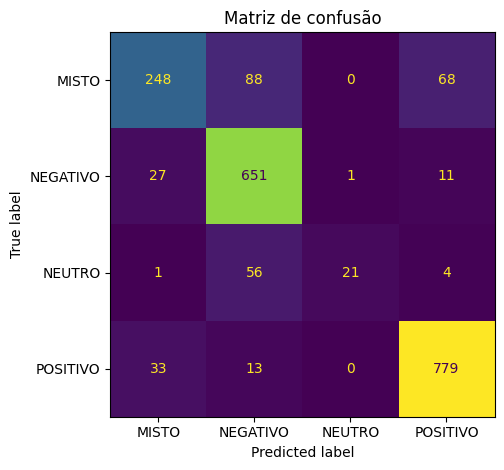

In [10]:
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

plt.figure(figsize=(5.2, 4.2))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False)
plt.title('Matriz de confusão')
plt.tight_layout()
plt.show()

## 11. Exemplos de acertos e erros
Inspecionamos algumas previsões para entender limitações do modelo.

In [11]:
results = pd.DataFrame({
    'text': X_test,
    'real': y_test,
    'pred': y_pred
})

errors = results[results['real'] != results['pred']]
hits = results[results['real'] == results['pred']]

print('Exemplos de acertos:')
hits.head(3)

Exemplos de acertos:


,text,real,pred
9603,"Ótima, gostei muito do produto . Uma pipoquei...",POSITIVO,POSITIVO
8879,nao recebi nao recebi o produto e quero ver mi...,NEGATIVO,NEGATIVO
1742,CESTA DESCASCANDO PRODUTO BOM ! COM EXCESSÃO D...,MISTO,MISTO


In [12]:
print('Exemplos de erros:')
errors.head(3)

Exemplos de erros:


,text,real,pred
7925,"Vale o preço Pochete mto útil, disfarça bem o ...",MISTO,POSITIVO
3915,Livro bom preço caro O valor do livro aumentou...,MISTO,POSITIVO
2056,Custo x benefício Este produto é aplicado para...,NEUTRO,NEGATIVO
